Практическая работа №6, вариант 7

Метод прогонки:
x1 = 1.090319
x2 = -0.638107
x3 = 2.610448
x4 = 1.581612

Метод простой итерации:
Количество итераций: 9
x1 = 1.090319
x2 = -0.638107
x3 = 2.610448
x4 = 1.581612

Метод Зейделя:
Количество итераций: 7
x1 = 1.090319
x2 = -0.638107
x3 = 2.610448
x4 = 1.581612

Проверка A*x для метода прогонки:
[12.143 13.089 13.674 13.897]


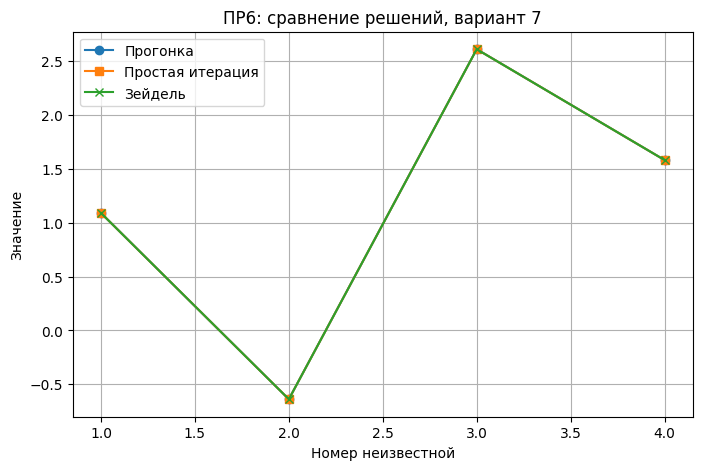

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Практическая работа №6
# Вариант 7
# Методы прогонки, простой итерации и Зейделя

A = np.array([
    [10.800, -0.576, 0.000,  0.000],
    [0.321,   9.900, 7.300,  0.000],
    [0.000,   0.369, 9.000, -6.060],
    [0.000,   0.000, 0.416,  8.100]
], dtype=float)

B = np.array([12.143, 13.089, 13.674, 13.897], dtype=float)

eps = 1e-6
max_iter = 100


def thomas_method(A, d):
    # метод прогонки для трехдиагональной матрицы
    n = len(d)
    a = np.zeros(n)  # нижняя диагональ
    b = np.zeros(n)  # главная диагональ
    c = np.zeros(n)  # верхняя диагональ

    for i in range(n):
        b[i] = A[i, i]
        if i > 0:
            a[i] = A[i, i-1]
        if i < n - 1:
            c[i] = A[i, i+1]

    cp = np.zeros(n)
    dp = np.zeros(n)

    cp[0] = c[0] / b[0]
    dp[0] = d[0] / b[0]

    for i in range(1, n):
        denom = b[i] - a[i] * cp[i-1]
        cp[i] = c[i] / denom if i < n - 1 else 0
        dp[i] = (d[i] - a[i] * dp[i-1]) / denom

    x = np.zeros(n)
    x[-1] = dp[-1]

    for i in range(n - 2, -1, -1):
        x[i] = dp[i] - cp[i] * x[i+1]

    return x


def to_iteration_form(A, B):
    n = len(B)
    alpha = np.zeros((n, n))
    beta = np.zeros(n)

    for i in range(n):
        beta[i] = B[i] / A[i, i]
        for j in range(n):
            if i != j:
                alpha[i, j] = -A[i, j] / A[i, i]

    return alpha, beta


alpha, beta = to_iteration_form(A, B)

# метод простой итерации
x = np.zeros(len(B))
simple_hist = [x.copy()]

for _ in range(max_iter):
    x_new = beta + alpha @ x
    simple_hist.append(x_new.copy())
    if np.linalg.norm(x_new - x, ord=np.inf) < eps:
        break
    x = x_new

# метод Зейделя
x = np.zeros(len(B))
seidel_hist = [x.copy()]

for _ in range(max_iter):
    x_old = x.copy()
    for i in range(len(B)):
        s1 = np.dot(A[i, :i], x[:i])
        s2 = np.dot(A[i, i+1:], x_old[i+1:])
        x[i] = (B[i] - s1 - s2) / A[i, i]
    seidel_hist.append(x.copy())
    if np.linalg.norm(x - x_old, ord=np.inf) < eps:
        break

x_thomas = thomas_method(A, B)
x_simple = simple_hist[-1]
x_seidel = seidel_hist[-1]

print("Практическая работа №6, вариант 7")

print("\nМетод прогонки:")
for i, val in enumerate(x_thomas, start=1):
    print(f"x{i} = {val:.6f}")

print("\nМетод простой итерации:")
print(f"Количество итераций: {len(simple_hist)-1}")
for i, val in enumerate(x_simple, start=1):
    print(f"x{i} = {val:.6f}")

print("\nМетод Зейделя:")
print(f"Количество итераций: {len(seidel_hist)-1}")
for i, val in enumerate(x_seidel, start=1):
    print(f"x{i} = {val:.6f}")

print("\nПроверка A*x для метода прогонки:")
print(np.round(A @ x_thomas, 6))

# график сходимости
simple_err = [
    np.linalg.norm(simple_hist[i] - simple_hist[i-1], ord=np.inf)
    for i in range(1, len(simple_hist))
]
seidel_err = [
    np.linalg.norm(seidel_hist[i] - seidel_hist[i-1], ord=np.inf)
    for i in range(1, len(seidel_hist))
]

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(simple_err)+1), simple_err, "o-", label="Простая итерация")
plt.plot(range(1, len(seidel_err)+1), seidel_err, "s-", label="Зейдель")
plt.axhline(eps, linestyle="--", label="eps")
plt.xlabel("Номер итерации")
plt.ylabel("Максимальная разность")
plt.title("ПР6: сходимость итерационных методов, вариант 7")
plt.legend()
plt.grid(True)
plt.savefig("pr6_convergence_variant7.png", dpi=150)
plt.close()

# сравнение решений
x_index = np.arange(1, 5)
plt.figure(figsize=(8, 5))
plt.plot(x_index, x_thomas, "o-", label="Прогонка")
plt.plot(x_index, x_simple, "s-", label="Простая итерация")
plt.plot(x_index, x_seidel, "x-", label="Зейдель")
plt.xlabel("Номер неизвестной")
plt.ylabel("Значение")
plt.title("ПР6: сравнение решений, вариант 7")
plt.legend()
plt.grid(True)
plt.savefig("pr6_solution_variant7.png", dpi=150)
plt.show()
plt.close()
